In [1]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast 

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


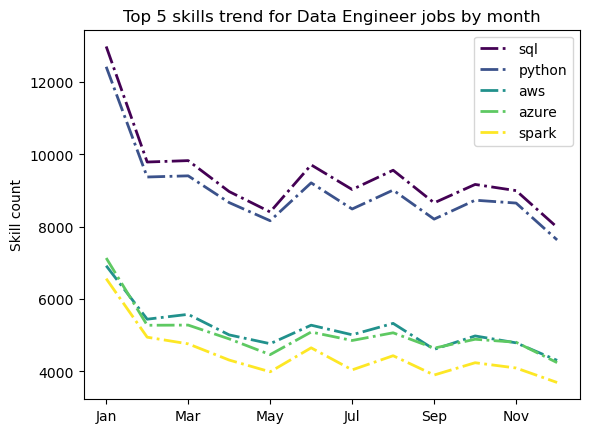

In [11]:
# --- 1. Data Preparation ---
# Filter for Data Engineer roles and explode the skills list so each skill gets its own row
# .copy() ensures we aren't working on a slice of the original dataframe
df_DE = df[df['job_title_short']=='Data Engineer'].explode('job_skills').copy()

# Extract the month number (1-12) to ensure chronological sorting later
df_DE['job_posted_month_no'] = df_DE['job_posted_date'].dt.month

# --- 2. Create the Skill-by-Month Matrix ---
# index = rows (months), columns = skills, aggfunc='size' counts occurrences
df_DE_pivot = df_DE.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

# --- 3. Sorting by Popularity (The "Total" Trick) ---
# Create a temporary 'Total' row to sum up occurrences for each skill across the whole year
df_DE_pivot.loc['Total'] = df_DE_pivot.sum()

# Reorder columns: Sort based on the values in the 'Total' row (highest frequency first)
df_DE_pivot = df_DE_pivot[df_DE_pivot.loc['Total'].sort_values(ascending=False).index]

# Remove the 'Total' row so it doesn't appear as a data point in our line chart
df_DE_pivot = df_DE_pivot.drop("Total")

# --- 4. Formatting Month Names ---
# Convert 1 -> 'Jan', 2 -> 'Feb', etc., for better readability on the X-axis
df_DE_pivot = df_DE_pivot.reset_index()
df_DE_pivot['job_posted_month'] = df_DE_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))

# Set the month name as the index and remove the helper number column
df_DE_pivot = df_DE_pivot.set_index('job_posted_month')
df_DE_pivot = df_DE_pivot.drop(columns='job_posted_month_no')

# --- 5. Visualization ---
# Plot only the first 5 columns (the Top 5 skills based on our previous sort)
df_DE_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth= 2,
    linestyle='-.', # options : , -- , -. , -
    colormap='viridis'
)

plt.xlabel('') # Removing 'job_posted_month' label for a cleaner look
plt.ylabel('Skill count')
plt.legend(title='') # Removes the default 'job_skills' title from the legend box
plt.title('Top 5 skills trend for Data Engineer jobs by month')
plt.show()